<a href="https://colab.research.google.com/github/YashaswiniDhornala/Computer-Vision/blob/main/Multiclass_classification1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!nvidia.smi

/bin/bash: line 1: nvidia.smi: command not found


In [4]:
!wget https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip

--2026-07-01 05:37:32--  https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip
Resolving bitbucket.org (bitbucket.org)... 104.192.142.24, 104.192.142.25, 104.192.142.26, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.24|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-07-01 05:37:33 ERROR 404: Not Found.



In [7]:
!unzip fruits.zip

Archive:  fruits.zip
   creating: fruits/
  inflating: __MACOSX/._fruits       
  inflating: fruits/.DS_Store        
  inflating: __MACOSX/fruits/._.DS_Store  
   creating: fruits/test/
   creating: fruits/train/
   creating: fruits/validation/
   creating: fruits/test/apple/
  inflating: fruits/test/.DS_Store   
  inflating: __MACOSX/fruits/test/._.DS_Store  
   creating: fruits/test/banana/
   creating: fruits/test/orange/
   creating: fruits/train/apple/
  inflating: fruits/train/.DS_Store  
  inflating: __MACOSX/fruits/train/._.DS_Store  
   creating: fruits/train/banana/
   creating: fruits/train/orange/
   creating: fruits/validation/apple/
  inflating: fruits/validation/.DS_Store  
  inflating: __MACOSX/fruits/validation/._.DS_Store  
   creating: fruits/validation/banana/
   creating: fruits/validation/orange/
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflating: __MACOSX/fruits/test/apple/._Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflatin

In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt


In [8]:
img_height, img_width = 32, 32
batch_size = 20

train_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/train",
    image_size = (img_height, img_width),
    batch_size = batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/validation",
    image_size = (img_height, img_width),
    batch_size = batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/test",
    image_size = (img_height, img_width),
    batch_size = batch_size
)

Found 460 files belonging to 3 classes.
Found 66 files belonging to 3 classes.
Found 130 files belonging to 3 classes.


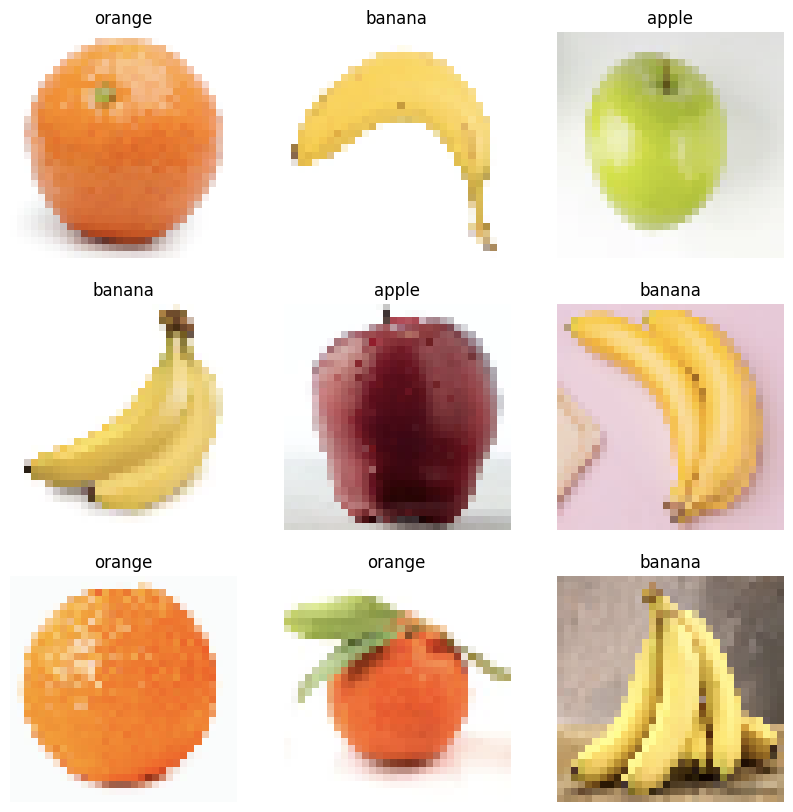

In [9]:
class_names = ["apple","banana",'orange']
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [10]:
model = tf.keras.Sequential(
    [tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="softmax"),
    tf.keras.layers.Dense(3)])

In [11]:
model.compile(
    optimizer ="rmsprop",
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [12]:
model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.3413 - loss: 1.0985 - val_accuracy: 0.3485 - val_loss: 1.0971
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.4152 - loss: 1.0922 - val_accuracy: 0.3333 - val_loss: 1.0834
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.4935 - loss: 1.0550 - val_accuracy: 0.4697 - val_loss: 1.0154
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.5935 - loss: 0.9998 - val_accuracy: 0.4545 - val_loss: 1.0074
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.6065 - loss: 0.9763 - val_accuracy: 0.6818 - val_loss: 0.9534
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.6761 - loss: 0.9526 - val_accuracy: 0.7273 - val_loss: 0.9459
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.7609 - loss: 0.9180 - val_accuracy: 0.6970 - val_loss: 0.9052
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.7652 - loss: 0.9002 - val_accuracy: 0.8788 -

In [13]:
model.evaluate(test_ds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.9538 - loss: 0.6019


[0.6018592715263367, 0.9538461565971375]

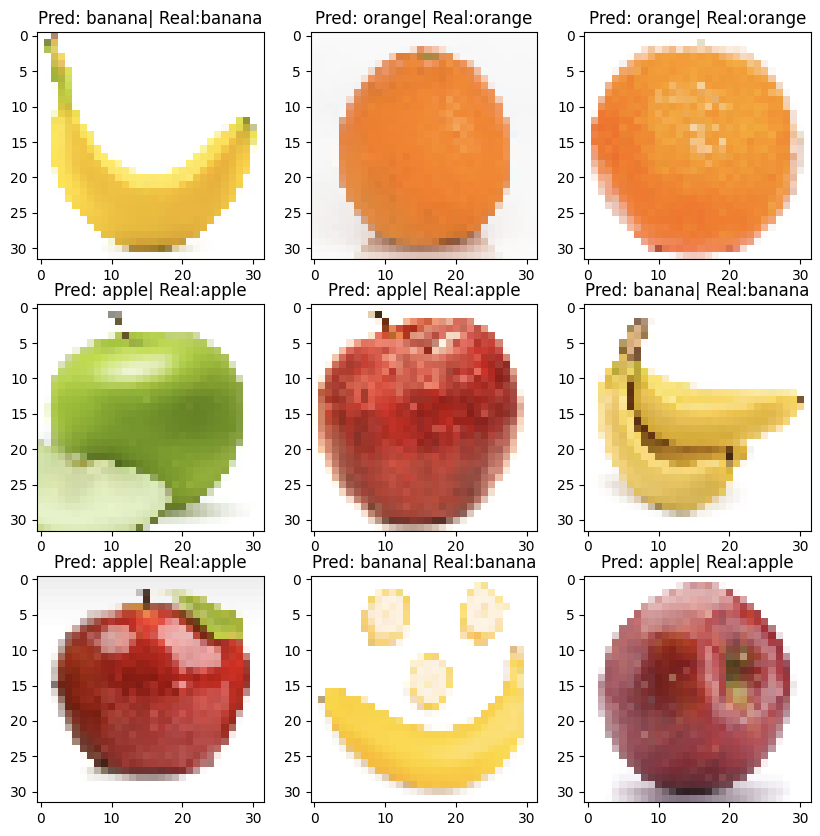

In [15]:
import numpy

plt.figure(figsize =(10,10))
for images, labels in test_ds.take(1):
  classifications = model(images)

for i in range(9):
  ax = plt.subplot(3,3,i+1)
  plt.imshow(images[i].numpy().astype("uint8"))
  index= numpy.argmax(classifications[i])
  plt.title("Pred: "+ class_names[index] +"| Real:" +class_names[labels[i]])

In [16]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", 'wb') as f:
  f.write(tflite_model)

Saved artifact at '/tmp/tmpebk482kd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139576697992016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139576697995088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139576697994512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139576697994704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139576694834192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139576694834960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139576694834000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139576694835920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139576694835344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139576694836880: TensorSpec(shape=(), dtype=tf.resource, name=None)
